The first step is to import all the libraries that will be used throughout the notebook. The code begins by importing numpy, which is a numerical computing library commonly used for handling arrays and mathematical operations. Then, tensorflow is imported — this library provides tools for building and training models, and it includes Keras, a high-level API that simplifies the model creation process.

After that, matplotlib.pyplot is imported as plt. This module is used for creating visualizations such as graphs and plots, which help in analyzing results during the process. The pandas library is also imported to make it easier to load and manage data, especially when working with structured formats like CSV files.

Finally, the code imports keras and layers from TensorFlow. keras provides the structure for building models, while layers contains predefined components that can be stacked together to form the architecture — such as fully connected layers, dropout layers, and more.

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow import keras
from tensorflow.keras import layers



---



In [ ]:
# Install the kaggle library
!pip install kaggle -q

# Import necessary library and upload your kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file")
files.upload()

# Move the file to the required directory and set permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Please upload your kaggle.json file


Saving kaggle.json to kaggle.json


In [ ]:
!rm -rf Image
!rm -f test-preliminary-round-fit-2025.zip

In [ ]:
# Download the dataset from Kaggle
!kaggle datasets download -d fitcompetition/test-preliminary-round-fit-2025

# Unzip the file in the current directory
!unzip -q test-preliminary-round-fit-2025.zip

Dataset URL: https://www.kaggle.com/datasets/fitcompetition/test-preliminary-round-fit-2025
License(s): other
 97% 511M/527M [00:03<00:00, 50.2MB/s]
100% 527M/527M [00:04<00:00, 127MB/s] 
mkdir: cannot create directory ‘Image’: File exists
mv: cannot stat 'PlantVillage': No such file or directory




---



These variables point to the same root folder, /content/Image_Class/PlantVillage, which contains the image data. These constants define the core parameters for processing the dataset. IMG_SIZE is set to a tuple of (180,180), which specifies the uniform dimensions all images will be resized to. This ensures that every input image has the same shape, a requirement for deep learning models. BATCH_SIZE determines the number of images to be processed together in one forward/backward pass during training. DATA_DIR simply stores the path to the root folder containing the image data.

In [ ]:
# Define core parameters
DATA_DIR = "Image/PlantVillage"
IMG_SIZE = (180, 180)
BATCH_SIZE = 32



---



This code loads the training dataset from the specified directory. The image_dataset_from_directory function is configured to create a split for validation by setting validation_split=0.2, which reserves 20% of the images. By specifying subset="training", this train_ds variable is assigned the first 80% of the data. The images are automatically resized to 180 * 180 pixels, labeled based on their subfolder names, and grouped into batches of 32. Using a seed ensures that the random shuffling and splitting are reproducible.

In [ ]:
# Create the training dataset (80% of data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


TensorFlow successfully scanned the folder and detected 20,638 image files organized into 15 different classes (or categories).



---



This line is used to get the list of class names from the training dataset

In [ ]:
data_cat = train_ds.class_names

When the image dataset was loaded earlier, TensorFlow automatically recognized the classes based on the folder names. The class_names attribute stores those class labels in the order they were assigned internally.

By assigning it to data_cat, we now have a list of all the class names in the dataset, which can be useful later — for example, when displaying predictions, labeling graphs, or simply checking which categories the model is being trained on.



---



This code creates the validation and testing datasets from the remaining 20% of the images set aside earlier. First, a temporary val_ds is created by setting subset="validation", ensuring it contains data that is completely separate from the training set.

To create a final, unseen test set, this validation data is further partitioned. The code takes approximately half of the batches from val_ds to create test_ds. The remaining batches are then assigned back to val_ds. This results in three distinct datasets: train_ds for training, val_ds for in-training validation, and test_ds for final, unbiased model evaluation.

In [ ]:
# Create the initial validation dataset (20% of data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Get the class names from the training dataset
class_names = train_ds.class_names
print("Class Names:", class_names)

# Further split the validation set into a smaller validation set and a test set
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Class Names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
print(f'Number of training batches: {tf.data.experimental.cardinality(train_ds)}')
print(f'Number of validation batches: {tf.data.experimental.cardinality(val_ds)}')
print(f'Number of testing batches: {tf.data.experimental.cardinality(test_ds)}')

Number of training batches: 516
Number of validation batches: 65
Number of testing batches: 64




---



This section is used to visually check a few images from the training dataset and make sure they’re labeled correctly. It starts by setting the figure size to 10 by 10 inches, which creates a large enough space to display multiple images clearly. Then, it takes one batch of images from the training data using .take(1), since each batch contains a number of image-label pairs (in this case, 32 images because of the earlier batch size setting).

From that batch, the code loops through the first 9 images. For each image, it creates a subplot using plt.subplot(3, 3, i+1) to arrange them in a 3x3 grid. Each image is displayed using plt.imshow(), and the corresponding class name is shown as the title using the label index mapped through data_cat. The .numpy().astype("uint8") part ensures the image is displayed in the correct format. Finally, the axis is turned off to make the visualization cleaner and easier to read.

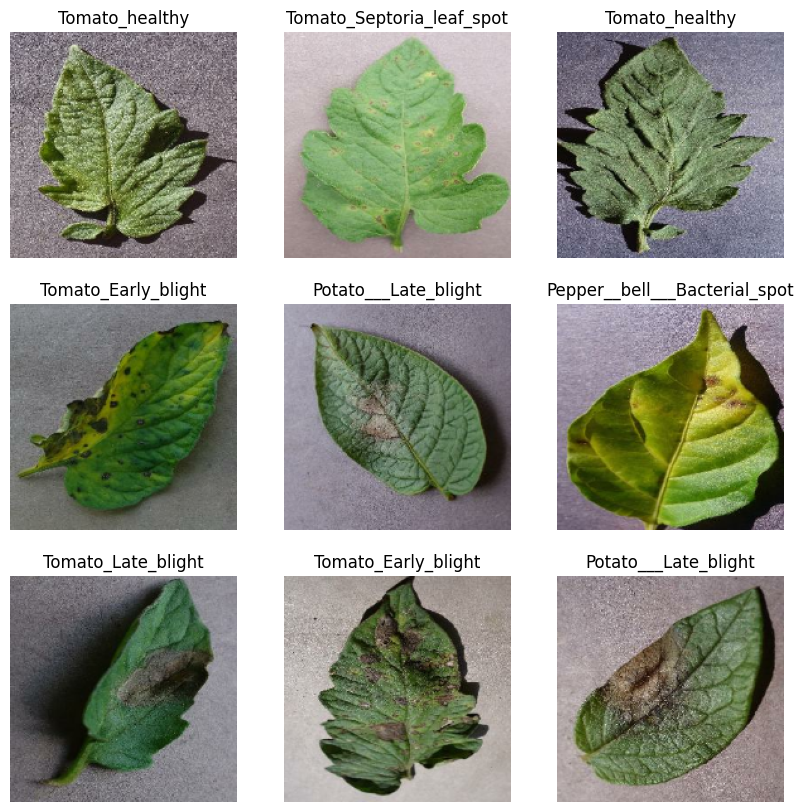

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")



---



This line imports the Sequential class from Keras, which is used to build a neural network model in a simple and straightforward way. With the Sequential model, we can add layers one by one in a linear stack — from the input layer all the way to the output. It’s a common choice when building models where each layer flows directly into the next, without needing any complex connections or branching. This setup is especially useful for tasks like image classification, where the model architecture is typically built step by step.

In [ ]:
from tensorflow.keras.models import Sequential



---



in this code cell, it simply returns a summary of the training dataset object that was created earlier using image_dataset_from_directory().



In [ ]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>



---



This block defines the complete model architecture. It starts with data augmentation layers (RandomFlip, RandomRotation, RandomZoom). These layers are only active during training and help prevent overfitting by showing the model slightly altered versions of the images in each epoch.

The model then includes a Rescaling layer to normalize pixel values, followed by three convolutional blocks (Conv2D and MaxPooling2D) to extract features. A Dropout layer is added for regularization before the data is flattened and passed to the final Dense layers for classification.

This block of code defines the structure of the model using the Sequential class. The model is built layer by layer, starting with a Rescaling layer that normalizes pixel values by dividing them by 255, converting the original range of 0–255 to 0–1. This helps the model train more efficiently.

Next, the model includes three convolutional blocks. Each block consists of a Conv2D layer followed by a MaxPooling2D layer. The convolution layers extract patterns from the images using small filters, while the max-pooling layers reduce the spatial size of the feature maps, making the model faster and reducing the risk of overfitting. The number of filters increases progressively from 16 to 32 to 64, allowing the model to learn more complex features at deeper levels.

After the convolution blocks, the output is flattened into a one-dimensional array using Flatten(), which prepares the data to be passed into dense (fully connected) layers. A Dropout layer is added next, which randomly disables a fraction (in this case, 20%) of the neurons during training to help prevent overfitting.

The model then includes a dense layer with 128 units to learn higher-level combinations of features, followed by the final output layer. The number of units in the last layer is set to len(data_cat), which matches the number of classes in the dataset — allowing the model to make a prediction for each class.

This setup is commonly used for image classification tasks and is designed to balance learning power with generalization.

In [ ]:
# Create a data augmentation layer
data_augmentation = Sequential(
  [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
  ]
)

# Build the model
model = Sequential([
  # Add the data augmentation and rescaling layers
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

  # Convolutional blocks
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),

  # Classifier head
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(len(class_names))
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)




---



The optimizer used here is 'adam', a popular and efficient choice that adjusts learning rates automatically during training. For the loss function, SparseCategoricalCrossentropy is used, which is suitable when the class labels are given as integers (not one-hot encoded). The from_logits=True argument is included because the final layer of the model does not have a softmax activation — so this tells the loss function to apply softmax internally.

Finally, the metric 'accuracy' is added so that the model’s performance can be tracked during training and validation. Accuracy measures how often the model predicts the correct class, and it's one of the most straightforward ways to evaluate classification models.

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])



---



In this section, the model is trained using the training dataset and evaluated on the validation dataset after each epoch. The number of training cycles, or epochs, is set to for a maximum and use an EarlyStopping callback. This stops training automatically when the validation loss stops improving, ensuring a more efficient process and preventing overfitting.

In this section, the model is trained using the train_ds and evaluated on the val_ds. We introduce an EarlyStopping callback to monitor the validation loss. Training will automatically stop if the validation loss does not improve for 3 consecutive epochs (patience=3), and the best weights will be restored. This is more effective than training for a fixed number of epochs.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train the model
epochs = 10 # Set a higher maximum number of epochs
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[early_stopping] # Add the callback
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 680s 1s/step - accuracy: 0.3756 - loss: 1.9107 - val_accuracy: 0.5734 - val_loss: 1.7094
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - accuracy: 0.7314 - loss: 0.7929 - val_accuracy: 0.6426 - val_loss: 1.3746
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 671s 1s/step - accuracy: 0.8120 - loss: 0.5579 - val_accuracy: 0.7489 - val_loss: 0.9597
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 686s 1s/step - accuracy: 0.8478 - loss: 0.4522 - val_accuracy: 0.7662 - val_loss: 0.8090
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 664s 1s/step - accuracy: 0.8635 - loss: 0.4031 - val_accuracy: 0.7369 - val_loss: 1.1551
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 675s 1s/step - accuracy: 0.8865 - loss: 0.3316 - val_accuracy: 0.8273 - val_loss: 0.6586
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 662s 1s/step - accuracy: 0.8948 - loss: 0.3074 - val_accuracy: 0.7268 - val_loss: 1.2916
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 677s 1s/step - accuracy: 0.9012 - loss: 0.2922 - val_accu

In [ ]:
# The first training session has already completed
# history = model.fit(...)

# Now, continue training for another 10 epochs
print("Continuing the training process...")
additional_epochs = 10

history_continued = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=additional_epochs,
  callbacks=[early_stopping] # You can reuse the same early stopping callback
)

Continuing the training process...
Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 688s 1s/step - accuracy: 0.9148 - loss: 0.2462 - val_accuracy: 0.8485 - val_loss: 0.5665
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 748s 1s/step - accuracy: 0.9222 - loss: 0.2193 - val_accuracy: 0.8273 - val_loss: 0.6614
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 689s 1s/step - accuracy: 0.9222 - loss: 0.2338 - val_accuracy: 0.8321 - val_loss: 0.6569
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.9295 - loss: 0.2040 - val_accuracy: 0.8639 - val_loss: 0.5465
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 688s 1s/step - accuracy: 0.9350 - loss: 0.1900 - val_accuracy: 0.9000 - val_loss: 0.3289
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 749s 1s/step - accuracy: 0.9406 - loss: 0.1710 - val_accuracy: 0.9115 - val_loss: 0.3133
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 721s 1s/step - accuracy: 0.9432 - loss: 0.1664 - val_accuracy: 0.8971 - val_loss: 0.3965
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 691s 1s/step - accurac



---



This section is used to visualize how the model performed during training. First, a range is created based on the number of epochs so that the x-axis of the plot lines up with each training round. A figure is then created with a size of 8 by 8 inches, and it’s split into two side-by-side plots.

The first plot shows how the model’s accuracy changed over time. It compares the training accuracy and validation accuracy for each epoch, helping to show whether the model is learning effectively and generalizing well to unseen data.

The second plot displays the loss values — again for both training and validation. Loss measures how far off the model's predictions are from the actual labels, so tracking it can help identify overfitting or underfitting.

Overall, these visualizations are useful for understanding how well the model is learning, and whether it's improving or struggling as training progresses.

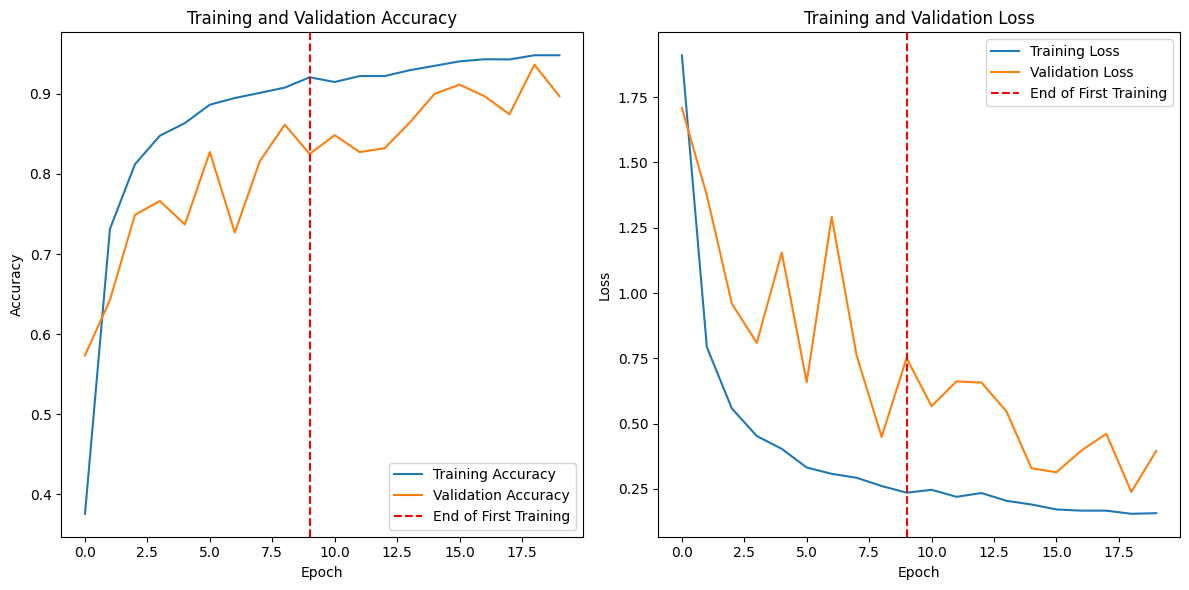

In [ ]:
import matplotlib.pyplot as plt

# Data from the first 10 epochs
acc_part1 = [0.3756, 0.7314, 0.8120, 0.8478, 0.8635, 0.8865, 0.8948, 0.9012, 0.9078, 0.9207]
loss_part1 = [1.9107, 0.7929, 0.5579, 0.4522, 0.4031, 0.3316, 0.3074, 0.2922, 0.2607, 0.2352]
val_acc_part1 = [0.5734, 0.6426, 0.7489, 0.7662, 0.7369, 0.8273, 0.7268, 0.8158, 0.8615, 0.8249]
val_loss_part1 = [1.7094, 1.3746, 0.9597, 0.8090, 1.1551, 0.6586, 1.2916, 0.7606, 0.4486, 0.7507]

# Data from the next 10 epochs
acc_part2 = [0.9148, 0.9222, 0.9222, 0.9295, 0.9350, 0.9406, 0.9432, 0.9430, 0.9482, 0.9482]
loss_part2 = [0.2462, 0.2193, 0.2338, 0.2040, 0.1900, 0.1710, 0.1664, 0.1663, 0.1543, 0.1567]
val_acc_part2 = [0.8485, 0.8273, 0.8321, 0.8639, 0.9000, 0.9115, 0.8971, 0.8745, 0.9365, 0.8971]
val_loss_part2 = [0.5665, 0.6614, 0.6569, 0.5465, 0.3289, 0.3133, 0.3965, 0.4609, 0.2380, 0.3953]

# Combine the data from both training sessions
acc = acc_part1 + acc_part2
loss = loss_part1 + loss_part2
val_acc = val_acc_part1 + val_acc_part2
val_loss = val_loss_part1 + val_loss_part2

# Create a range for the total number of epochs
epoch_range = range(len(acc))

# Plot the combined data
plt.figure(figsize=(12, 6))

# Plot for accuracy
plt.subplot(1, 2, 1)
plt.plot(epoch_range, acc, label='Training Accuracy')
plt.plot(epoch_range, val_acc, label='Validation Accuracy')
plt.axvline(x=9, color='r', linestyle='--', label='End of First Training') # Mark where training was continued
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')


# Plot for loss
plt.subplot(1, 2, 2)
plt.plot(epoch_range, loss, label='Training Loss')
plt.plot(epoch_range, val_loss, label='Validation Loss')
plt.axvline(x=9, color='r', linestyle='--', label='End of First Training') # Mark where training was continued
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

The two plots above show how the model’s performance changed during the training process over 20 epochs.

On the left, the accuracy graph shows a steady improvement for both training and validation data. The training accuracy starts at around 57% and increases to over 93% by the ninth epoch. The validation accuracy also shows a upward trend, eventually leveling off just below 95%. This suggests that the model is learning effectively and is also able to generalize well to unseen validation data.

On the right, the loss graph shows a clear downward trend, which is what we want to see. Both training loss and validation loss decrease in trend with each epoch. The training loss drops more quickly and ends up lower than the validation loss, which could indicate that the model is not overfitting great with only 20 epoch (could increase more of there was more time) and is actually performing slightly better on training data.

Overall, these results show that the model is improving with each training cycle, without showing signs of overfitting. If needed, more epochs could be added to further refine the model, but even at this stage, the performance is already promising.



---



In this step, a random image from the original dataset was selected manually and saved as test.JPG to be used for testing the model. The image is first loaded and resized to 180x180 pixels to match the input shape the model was trained on. After that, it’s converted into a numerical array and expanded into a batch format, since the model expects inputs in batches even if it's just one image.

By doing this, the image is fully prepared and ready to be passed into the model for prediction. This approach is useful for manually checking how well the model performs on specific, real examples from the dataset.

In [ ]:
# Define the path to a sample image within the dataset
# Replace this path with the actual path to the image you want to test
image_path = "Image/PlantVillage/Pepper__bell___Bacterial_spot/00f2e69a-1e56-412d-8a79-fdce794a17e4___JR_B.Spot 3132.JPG"

# Load the image
image = tf.keras.utils.load_img(image_path, target_size=(180, 180))
img_arr = tf.keras.utils.img_to_array(image)
img_bat = tf.expand_dims(img_arr, 0)



---



At this point, the image has already been resized, converted to an array, and wrapped in a batch format. The model.predict() function takes that input and returns the model’s output — in this case, a raw prediction score (or a set of scores) for each class in the dataset.

The result is stored in the predict variable, which contains the model’s confidence scores for all 15 classes. The class with the highest score represents the model’s final prediction for the image.

In [ ]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step




---



The original output from the model (predict) consists of unnormalized scores called logits. These values aren’t easy to interpret directly, so tf.nn.softmax() is used to transform them into a probability distribution — where all values add up to 1, and each one represents the model’s confidence that the image belongs to a particular class.

The result is stored in score, which can now be used to identify the most likely class by checking which value is the highest. This makes it much easier to understand and display the prediction result.










In [ ]:
score = tf.nn.softmax(predict)



---



This line prints out the final prediction result, showing the predicted leaf type along with the model’s confidence percentage

In [ ]:
print("The leaf type is {} with accuracy {:0.2f}".format(data_cat[np.argmax(score)].replace('_', ' '), 100*np.max(score)))

The leaf type is Tomato Septoria leaf spot with accuracy 97.67




---



This block of code is used to evaluate the model's performance across the entire test dataset, not just a small sample.

First, it initializes two empty lists to store all the model's predictions and the corresponding actual labels from the test set. The code then iterates through every batch of images and labels in the

test_ds. In each iteration, it uses

model.predict() on the batch of images to get the raw prediction scores (logits) and appends these scores and the true labels to the lists.

After processing all the batches, the lists of predictions and labels are converted into single NumPy arrays for easier computation. The final predicted class for each image is determined by finding the index with the highest score using

np.argmax().

Finally, these complete sets of predicted and actual labels are used to generate a comprehensive

classification_report from scikit-learn. This report provides detailed metrics such as

precision, recall, and f1-score for each class, offering a robust, quantitative assessment of the model's performance instead of a manual review of a few images.

In [ ]:
# Collect predictions and actual labels for the entire test dataset
all_predictions = []
all_actual_labels = []

for images, labels in test_ds:
    predictions = model.predict(images)
    all_predictions.append(predictions)
    all_actual_labels.append(labels.numpy())

# Concatenate results from all batches
all_predictions = np.concatenate(all_predictions, axis=0)
all_actual_labels = np.concatenate(all_actual_labels, axis=0)

# Get the predicted class for each image
predicted_classes = np.argmax(all_predictions, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Generate a classification report
# This report includes precision, recall, f1-score, and support for each class
report = classification_report(all_actual_labels, predicted_classes, target_names=class_names)
print(report)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.90      0.83      0.86        87
                     Pepper__bell___healthy       0.94      0.97      0.95       128
                      Potato___Early_blight       0.89      0.93      0.91        84
                       Potato___Late_blight       0.93      0.68      0.79       119
                           Potato___healthy       0.77      0.59      0.67        17
                      Tomato_Bacterial_spot       0.98      0.77      0.86       210
                        Tomato_Early_blight       0.71      0.85      0.77       106
                         Tomato_Late_blight       0.95      0.79      0.86       180
                           Tomato_Leaf_Mold       0.97      0.79      0.87        96
                  Tomato_Septoria_leaf_spot       0.77      0.97      0.86       167
Tomato_Spider_mites_Two_spotted_spider_mite       0.90      0.76